# Convergence clubs in labor productivity and its proximate sources

![Alt text](https://monosnap.com/image/8Y97u2HCKH3chLCAZy33O1efYwDvLv)

[![DOI](https://zenodo.org/badge/268529303.svg)](https://zenodo.org/badge/latestdoi/268529303)

Testing for economic convergence across countries has been a central issue in the literature of economic growth and development. This book introduces a modern framework to study the cross-country convergence dynamics of labor productivity and its proximate sources: capital accumulation and aggregate efficiency. In particular, recent convergence dynamics of developed as well as developing countries are evaluated through the lens of a non-linear dynamic factor model and a clustering algorithm for panel data. This framework allows us to examine key economic phenomena such as technological heterogeneity and multiple equilibria. Overall, the book provides a succinct review of the recent club convergence literature, a comparative view of developed and developing countries, and a tutorial on how to implement the club convergence framework. These three features will help graduate students and researchers catch up with the latest developments and methodological implementations of the club convergence literature.

- About the author: <https://carlos-mendez.org>
- Read the book online: [Only for Nagoya University students](https://ebookcentral.proquest.com/lib/nagoyauniv/detail.action?docID=6386038)
- [Buy the ebook](https://www.springer.com/gp/book/9789811586286)
- [Buy the book](https://www.amazon.co.jp/Convergence-Clubs-Productivity-Proximate-Sources/dp/9811586284/ref=sr_1_1?dchild=1&keywords=%22Convergence+Clubs+in+Labor+Productivity+and+its+Proximate+Sources%22&qid=1599180007&sr=8-1)

**Table of contents**

1.  Introduction and overview
2.  Measuring labor productivity and its proximate sources
3.  A modern framework to study convergence
4.	Convergence clubs in labor productivity
5.  Convergence clubs in capital accumulation
6.  Convergence clubs in aggregate efficiency
7.  Concluding remarks and new research directions


| Tutorials                                                                                                                                                                | Download datasets                                                                                                        |
|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------|
| [Video Tutorial](https://youtu.be/FO8Ngl57HRQ)                                                                                                                           | [Download full dataset](assets/dat.csv.zip?raw=true)                                                                     |
| [Convergence clubs analysis using Stata](https://github.com/quarcs-lab/mendez2020-convergence-clubs-code-data/raw/master/assets/tutorial-hiYes_log_lp.zip)                                                                                      | [Download dataset definitions](assets/dat-definitions.csv.zip?raw=true); [See dataset definitions](/dat-definitions.csv) |
| [Convergence clubs analysis using R](https://colab.research.google.com/drive/1GjO43UJIhtqX39qja5yUl4j9suwKIpMl?usp=sharing)                                                                  | [Download R dataset of developed countries](assets/dat_hiNo.zip?raw=true)                                                |
| [Explore  the data using Python in Deepnote](https://deepnote.com/@Dev-macro/Explore-labor-productivity-data-TvVTPkcdQPiAYlLIfPZG7g)                                     | [Download R dataset of developing countries](assets/dat_hiYes.zip?raw=true)                                              |
| [Explore the data using Python in Google Colab](https://colab.research.google.com/github/quarcs-lab/mendez2020-convergence-clubs-code-data/blob/master/assets/dat.ipynb) |                                                                                                                          |
| [Explore the data using R in R Studio Cloud](https://rstudio.cloud/project/2047179)                                                                                      |                                                                                                                          |



# Setup

In [1]:
install.packages("ConvergenceClubs")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘zoo’, ‘lmtest’, ‘sandwich’




In [2]:
library(tidyverse)
library(haven)
library(ConvergenceClubs)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# Data: Import, select, transform

In [3]:
df_long <- read_stata("https://github.com/quarcs-lab/mendez2020-convergence-clubs-code-data/raw/master/assets/dat.dta")
df_long %>% head()

id,country,year,Y,K,pop,L,s,alpha_it,GDPpc,⋯,log_h_raw,log_tfp_raw,log_GDPpc,log_lp,log_ky,log_h,log_tfp,isocode,hi1990,region
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
1,Albania,1990,12450,31217,3.281453,1.2500960,8.497386,NA,3794.051,⋯,1.152197,5.560511,8.130327,9.209681,0.8807698,1.125790,5.541879,ALB,no,Europe
1,Albania,1991,11310,30082,3.275438,1.2437190,8.442703,NA,3452.973,⋯,1.147513,5.479933,8.170837,9.268303,0.8696046,1.133772,5.574306,ALB,no,Europe
1,Albania,1992,10122,28968,3.240613,0.9934920,8.388020,NA,3123.483,⋯,1.142817,5.457089,8.211625,9.326916,0.8585356,1.141821,5.606780,ALB,no,Europe
1,Albania,1993,11636,29010,3.189623,0.9359275,8.333337,NA,3648.080,⋯,1.138110,5.617254,8.252907,9.385130,0.8479305,1.150036,5.639110,ALB,no,Europe
1,Albania,1994,13120,29634,3.140634,1.0086870,8.278653,NA,4177.500,⋯,1.133391,5.707116,8.294488,9.442308,0.8386395,1.158520,5.670734,ALB,no,Europe
1,Albania,1995,14264,30538,3.106727,0.9628795,8.223970,NA,4591.327,⋯,1.128661,5.797699,8.336048,9.497923,0.8316767,1.167347,5.701035,ALB,no,Europe


In [4]:
sample <- df_long %>%
  filter(hi1990 == "yes") %>%
  #filter(hi1990 == "no") %>%
  #filter(region == "Africa") %>%
  #filter(region == "Asia") %>%
  #filter(region == "Americas") %>%
  #filter(region == "Europe") %>%
  select(country, year, log_lp) %>%
  #select(country, year, log_ky) %>%
  #select(country, year, log_h) %>%
  #select(country, year, log_tfp) %>%
  as.data.frame()

In [5]:
sample

country,year,log_lp
<chr>,<dbl>,<dbl>
Australia,1990,11.05017
Australia,1991,11.07393
Australia,1992,11.09764
Australia,1993,11.12112
Australia,1994,11.14427
Australia,1995,11.16695
Australia,1996,11.18907
Australia,1997,11.21047
Australia,1998,11.23099


In [6]:
sample <- sample %>%
  rename(Y = names(.)[3])

In [7]:
df_wide <- sample %>%
  pivot_wider(names_from = year, values_from = Y) %>%
  as.data.frame()

In [8]:
df_wide

country,1990,1991,1992,1993,1994,1995,1996,1997,1998,⋯,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Australia,11.05017,11.07393,11.09764,11.12112,11.14427,11.16695,11.18907,11.21047,11.23099,⋯,11.34128,11.35193,11.36142,11.36985,11.37736,11.38408,11.39012,11.39562,11.40083,11.40592
Austria,10.91387,10.94536,10.97672,11.00780,11.03837,11.06816,11.09692,11.12441,11.15036,⋯,11.28117,11.29344,11.30455,11.31472,11.32420,11.33326,11.34212,11.35090,11.35967,11.36844
Belgium,11.05338,11.07806,11.10268,11.12709,11.15118,11.17480,11.19778,11.22001,11.24122,⋯,11.34825,11.35798,11.36689,11.37520,11.38305,11.39055,11.39778,11.40484,11.41180,11.41870
Canada,11.04026,11.05845,11.07664,11.09475,11.11269,11.13035,11.14757,11.16424,11.18023,⋯,11.26337,11.27068,11.27688,11.28213,11.28660,11.29061,11.29431,11.29781,11.30123,11.30464
Denmark,10.82652,10.85686,10.88718,10.91740,10.94747,10.97729,11.00673,11.03567,11.06393,⋯,11.23470,11.25579,11.27637,11.29658,11.31652,11.33625,11.35573,11.37499,11.39409,11.41312
Finland,10.79930,10.83889,10.87846,10.91782,10.95665,10.99454,11.03106,11.06592,11.09875,⋯,11.25741,11.27054,11.28168,11.29099,11.29875,11.30531,11.31100,11.31612,11.32094,11.32565
France,10.98581,11.00712,11.02846,11.04984,11.07130,11.09282,11.11439,11.13589,11.15714,⋯,11.28974,11.30686,11.32372,11.34035,11.35682,11.37319,11.38951,11.40581,11.42211,11.43841
Germany,10.87811,10.90749,10.93671,10.96561,10.99403,11.02185,11.04894,11.07524,11.10066,⋯,11.25234,11.27019,11.28700,11.30286,11.31794,11.33252,11.34676,11.36079,11.37474,11.38868
Greece,10.64756,10.67652,10.70538,10.73408,10.76256,10.79072,10.81841,10.84541,10.87145,⋯,11.01248,11.02645,11.03930,11.05122,11.06242,11.07320,11.08385,11.09458,11.10540,11.11621


In [9]:
h <- computeH(df_wide[,-1], quantity = "h")

In [10]:
df_h <- data.frame(h)

country_names <- df_wide %>%
  select(country)

h_wide <- cbind(country_names, df_h)

In [11]:
h_wide

country,X1990,X1991,X1992,X1993,X1994,X1995,X1996,X1997,X1998,⋯,X2005,X2006,X2007,X2008,X2009,X2010,X2011,X2012,X2013,X2014
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Australia,1.0156990,1.0151580,1.0146156,1.0140619,1.0134899,1.0128972,1.0122830,1.0116471,1.0109917,⋯,1.0062125,1.0055197,1.0048251,1.0041266,1.0034150,1.0026840,1.0019285,1.0011509,1.0003616,0.9995702
Austria,1.0031710,1.0033713,1.0035606,1.0037282,1.0038591,1.0039363,1.0039461,1.0038802,1.0037333,⋯,1.0008797,1.0003389,0.9997960,0.9992573,0.9987268,0.9982082,0.9977064,0.9972219,0.9967499,0.9962855
Belgium,1.0159935,1.0155366,1.0150766,1.0146061,1.0141190,1.0136083,1.0130711,1.0125072,1.0119123,⋯,1.0068305,1.0060551,1.0053093,1.0045985,1.0039172,1.0032542,1.0026025,1.0019607,1.0013241,1.0006901
Canada,1.0147882,1.0137384,1.0126956,1.0116568,1.0106187,1.0095768,1.0085283,1.0074749,1.0064216,⋯,0.9993003,0.9983227,0.9973488,0.9963790,0.9954113,0.9944517,0.9935009,0.9925580,0.9916226,0.9906940
Denmark,0.9951421,0.9952592,0.9953741,0.9954857,0.9955929,0.9956933,0.9957863,0.9958724,0.9959525,⋯,0.9967568,0.9970042,0.9973038,0.9976555,0.9980496,0.9984710,0.9989039,0.9993383,0.9997704,1.0002007
Finland,0.9926394,0.9936112,0.9945769,0.9955239,0.9964274,0.9972580,0.9979878,0.9986027,0.9990871,⋯,0.9987712,0.9983106,0.9977734,0.9971619,0.9964820,0.9957459,0.9949689,0.9941664,0.9933517,0.9925357
France,1.0097832,1.0090335,1.0082908,1.0075620,1.0068538,1.0061732,1.0055264,1.0049169,1.0043439,⋯,1.0016396,1.0015272,1.0014915,1.0015213,1.0016036,1.0017247,1.0018750,1.0020457,1.0022291,1.0024168
Germany,0.9998832,0.9998998,0.9999025,0.9998812,0.9998274,0.9997353,0.9996055,0.9994435,0.9992592,⋯,0.9983220,0.9982791,0.9982440,0.9982101,0.9981751,0.9981427,0.9981144,0.9980906,0.9980729,0.9980591
Greece,0.9786918,0.9787272,0.9787531,0.9787698,0.9787767,0.9787710,0.9787487,0.9787032,0.9786266,⋯,0.9770408,0.9766897,0.9763365,0.9759862,0.9756398,0.9753025,0.9749880,0.9747034,0.9744393,0.9741811


In [12]:
h_long <- pivot_longer(h_wide,
             starts_with("X"),
             names_to = "year",
             names_prefix = "X",
             values_to = "h")

In [13]:
h_long

country,year,h
<chr>,<chr>,<dbl>
Australia,1990,1.0156990
Australia,1991,1.0151580
Australia,1992,1.0146156
Australia,1993,1.0140619
Australia,1994,1.0134899
Australia,1995,1.0128972
Australia,1996,1.0122830
Australia,1997,1.0116471
Australia,1998,1.0109917


# Transition paths

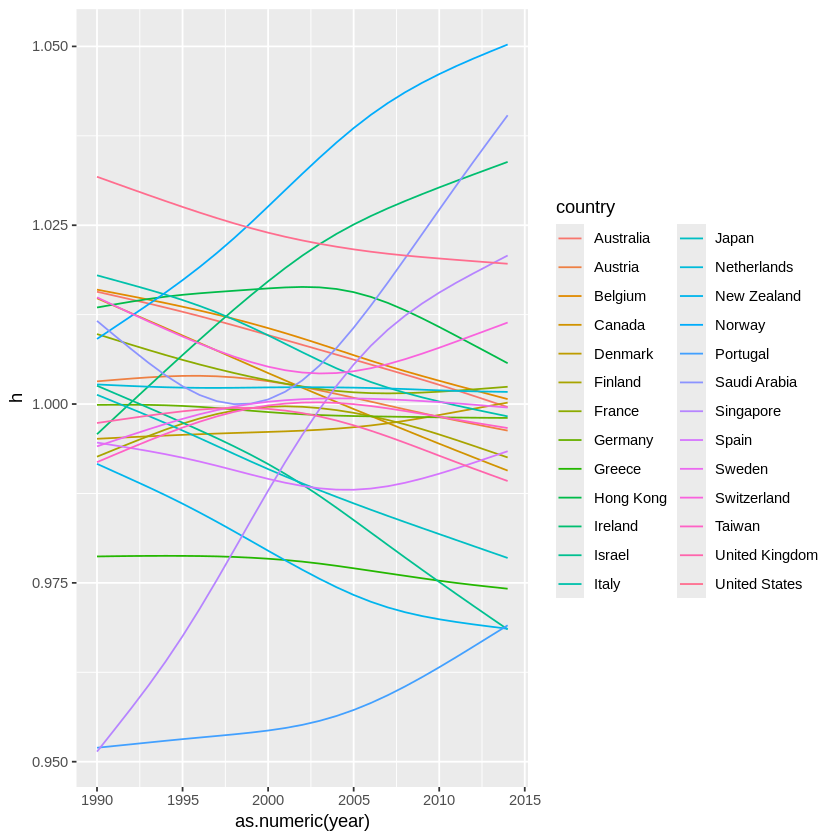

In [14]:
h_long %>%
  ggplot(aes(x = as.numeric(year), y = h, color = country)) +
  geom_line()

# Convergence test: Log-t

In [15]:
H <- computeH(df_wide[,-1], quantity = "H")

In [16]:
round(estimateMod(H, time_trim=1/3, HACmethod = "FQSB"),2)

beta std.err  tvalue  pvalue 
  -1.40    0.05  -28.62    0.00

# Convergence clubs

In [17]:
clubs <- findClubs(df_wide,
                   dataCols=2:ncol(df_wide),
                   unit_names = 1,
                   refCol=ncol(df_wide),
                   time_trim =0.3,
                   cstar=0,
                   HACmethod = 'FQSB')
summary(clubs)

Number of convergence clubs: 4
Number of divergent units: 1

        | # of units  | beta     | std.err  | tvalue   | cstar  
-------- ------------- ---------- ---------- ---------- --------
 club1  |   5         |   0.206  |   0.09   |   2.287  |   0    
 club2  |   15        |   0.17   |   0.076  |   2.245  |   0    
 club3  |   3         |   0.111  |   0.047  |   2.349  |   0    
 club4  |   2         |   4.589  |   1.867  |   2.459  |   0    


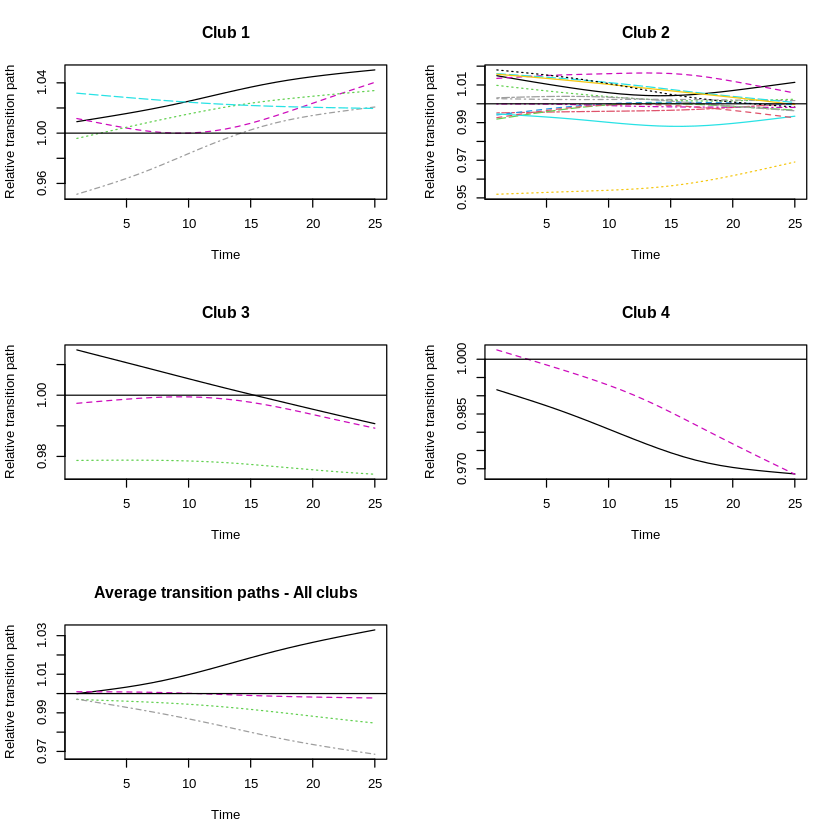

In [18]:
plot(clubs)

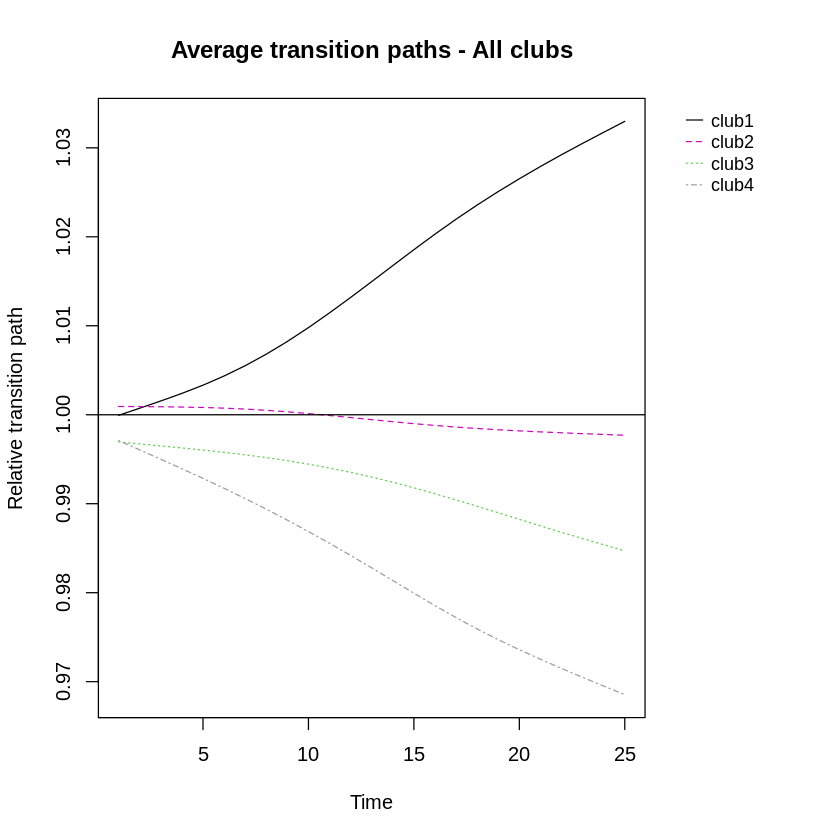

In [19]:
plot(clubs, clubs=NULL, avgTP = TRUE, legend=TRUE)

# Merge test

In [20]:
mclubs_PS <- mergeClubs(clubs, mergeMethod='PS', mergeDivergent=FALSE)
summary(mclubs_PS)

Number of convergence clubs: 3
Number of divergent units: 1

        | merged clubs  | # of units  | beta     | std.err  | tvalue   
-------- --------------- ------------- ---------- ---------- ----------
 club1  | clubs: 1      |   5         |   0.206  |   0.09   |   2.287  
 club2  | clubs: 2, 3   |   18        |  -0.058  |   0.056  |  -1.047  
 club3  | clubs: 4      |   2         |   4.589  |   1.867  |   2.459  


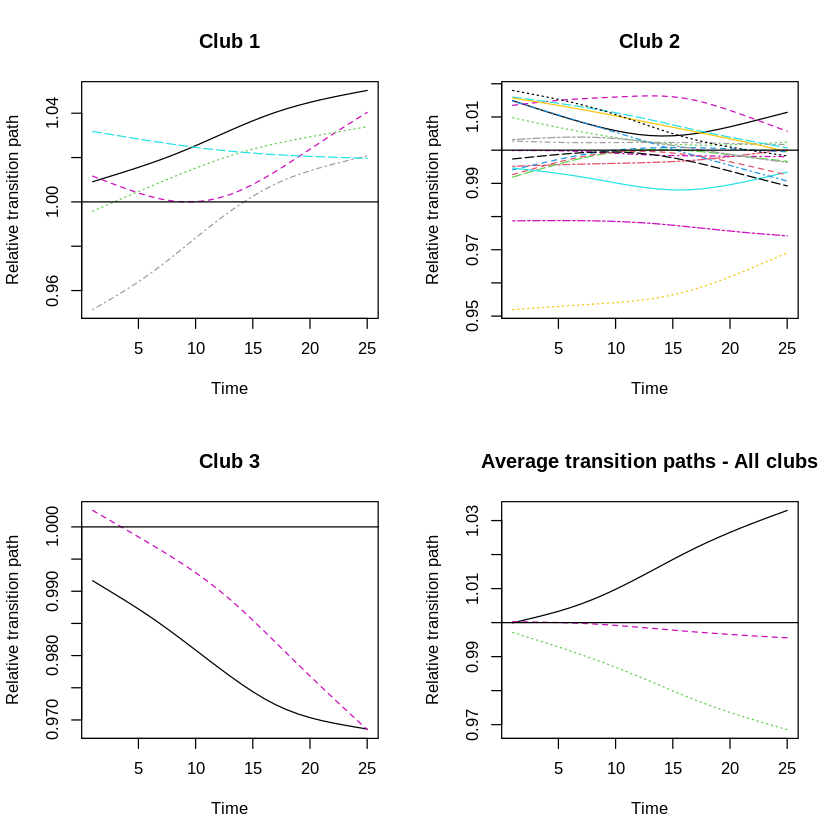

In [21]:
plot(mclubs_PS)

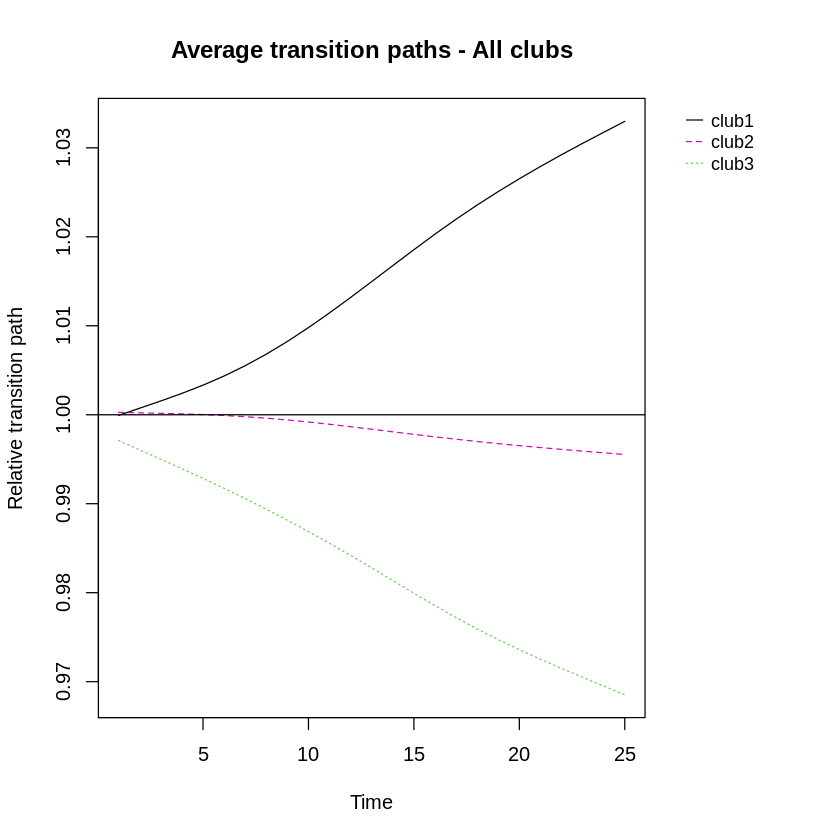

In [22]:
plot(mclubs_PS, clubs=NULL, avgTP = TRUE, legend=TRUE)

List of countries in each club:

In [23]:
mclubs_PS

======================================================================== 
club 1
------------------------------------------------------------------------ 
Norway, Saudi Arabia, Ireland, Singapore, United States

beta:      0.206 
std.err:   0.0901 
tvalue:    2.2874 
pvalue:    0.9889 

======================================================================== 
club 2
------------------------------------------------------------------------ 
Switzerland, Hong Kong, France, Netherlands, Belgium, Denmark, 
Australia, Sweden, Italy, Germany, Taiwan, Austria, Spain, Finland, 
Portugal, Canada, United Kingdom, Greece

beta:     -0.0582 
std.err:   0.0556 
tvalue:   -1.0467 
pvalue:    0.1476 

======================================================================== 
club 3
------------------------------------------------------------------------ 
New Zealand, Israel

beta:      4.5892 
std.err:   1.8665 
tvalue:    2.4587 
pvalue:    0.993 

======================================================================== 
divergent
------------------------------------------------------------------------ 
Japan